In [31]:
from utils import * 
import subprocess
import json
from ppi import * 
import itertools
import requests

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
get_num_subunits = lambda name : int(re.search(r'(\d+)mer', name).group(1))

In [22]:
# No genes in this cluster have any InterProScan annotations. 

In [23]:
DSSP_OUTPUT_DIR = '../data/genes/dssp/'

ALPHAFOLD_DIR = '../data/genes/alphafold/'
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/server/'

In [24]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['gene_id'] = genes_df.index
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id == 6].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_6.faa')
# subprocess.run('muscle -align ../data/genes/cluster_6.faa -output ../data/genes/cluster_6.afa', shell=True, check=True)
for row in genes_df.itertuples():
    print(f'{row.Index}\t{row.seq}')

print('\nMinimum cluster_6 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_6 gene length:', genes_df.seq.apply(len).max())

msa = MSAFile.from_file('../data/genes/cluster_6.afa')

orfm.bz_0.1_169	MWNPFKTLTKNAPTIKDISRIPSDIKDSAYNIKANKITIRYFMDLNFTDSQDITGELVHNKGLPIVIFERPFSGAILFSESCVYRNHTKDGELTMDLVKDYPFGIDHKSDLFKYNGIEYTNNQYEIRITDKSLEQYYSKKYKFYIPIMLNRTPIPIIRLDKADRILNKVDEKNVKRLSNITQTFLREFTRLKLLERTGTKKDGVGWILFFGWMAGLATYAIVSLFVK
orfm.bz_1.1_143	MGFFDGIEKIKLPNIGNLIHEGKDIKTQIKKIDINGINVRYWNKDCTYYTPTKGIIYRYTNVSLVIMKIPEKLGVIIIDNTIHFNKFTKEEELDVIEGFGFTVDLSHQPILEKELSELKTIIAKKEIKDIKNYTIPAMINKIPVPIVRVNLNQNLGTLPDYVAISQKFLYEISMVKILQKVNKQKHEGLFIVLVLGIFIGIFLGSAMMGYILR
orfm.bz_2.1_38	MSFSSTLKSIKFPDTKEALETPSRIREETDKTNLNHITVMYFTRKFAKCIRVKGVISHETSVPIIYFNKPENLGIIDFDNTSFYDETLKELCIIVSEDYLFSLDMNSEYKLIHNLKIQYYNDTIRYKAKSKDIKKIGNRGKLLFEKTNCAYMLPIFLNNIPREVIKINIENNVLDNTIQDSDVEEKNTQIEEKILNDYDKKIEVTQYIVRQFATVKMLSNLQKPNNSIIIACALMFIPLGLIMGIFITLFFFR
orfm.bz_3.1_56	MGFFNKLSKADLPESQDIIEIPKKLKEQSDNSKLNDITVRFFNQDFSKVIESIGKISHKTSIPIIYFDKPEKLAVIMFDDTSYIDVTRNNKLCIDVCESYPYAIDKNISIFRDDKIKYFNEKYKKSYKELEEIYKKSERKLYIPILLNNIPIPIIEIEKNYKTSMINGEWITHKKTITMNLIRQLSDIKLLERVGKKDNSALMFCALLFLLIGILTGFIMAIWVIG
orfm.bz_4.1_159

In [28]:
# It seems as though ColabFold was able to generate reasonable MSAs for these, but for AlphaFold3, there will be a considerable speed-up if using the MSAs from the analysis-1-cluster.ipynb
# notebook. My worry is that the structure quality could be reduced if fewer sequences are included in the MSA, but I will evaluate this using the AlphaFold server. 

ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/cluster_6-multimer' # Directory name to match what is required on biotite.
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output' # Directory name to match what is required on biotite.

# Generate the input files for the local version of AlphaFold3 on biotite. For now, I will just use the automatically-generated MSAs, 
# which seem to produce higher-confidence structures than the custom MSA with 10 sequences. 

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 10 # Number of recycles to use during inference (refinement steps). 10 by default. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

msas = get_msas_unpaired(genes_df.index.tolist())
names = list()
for row in genes_df.itertuples():

    for n in range(2, 10):

        input = AlphaFoldInputFile(f'{row.genome_id}_cluster_6_{n}mer', version=2, num_seeds=10)
        input.add_seq(row.seq, n=n, paired_msa='', unpaired_msa=msas[row.Index])
        input.write(os.path.join(ALPHAFOLD_INPUT_DIR, input.name + '.json'))
        names.append(input.name)

# print('sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_3/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"')
cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_6-multimer/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 10"


Loaded 80 cluster_6 multimer structures.



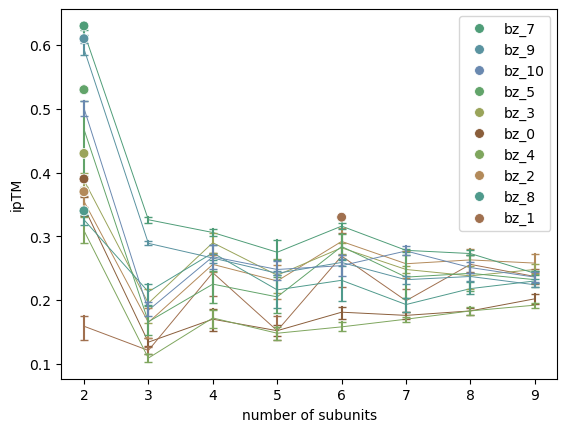

In [ ]:
if not os.path.exists('analysis-1-cluster_6-figure_1.csv'):

    outputs = [AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, name)) for name in names]
    print('Loaded', len(outputs), 'cluster_6 multimer structures.', end='\n\n')
    
    figure_df = list()
    for output in outputs:
        for model, iptm in output.get_iptms(mean_pool=False).items():
            row = {'name':output.name, 'model':model, 'iptm':iptm, 'genome_id':get_genome_id(output.name)}
            row['best_model'] = output.best_model == model
            row['num_subunits'] = get_num_subunits(output.name)
            figure_df.append(row)
    figure_df = pd.DataFrame(figure_df)
    figure_df.to_csv('analysis-1-cluster_6-figure_1.csv')
else:
    figure_df = pd.read_csv('analysis-1-cluster_6-figure_1.csv', index_col=0)

fig, ax = plt.subplots()
y = 'iptm'

sns.lineplot(figure_df, x='num_subunits', y=y, hue='genome_id', lw=0.7, palette=GENOME_ID_COLORS, zorder=-1,legend=False, err_style='bars', err_kws={"capsize": 3})
sns.scatterplot(figure_df.sort_values('iptm', ascending=False).drop_duplicates('genome_id'), x='num_subunits', y=y, hue='genome_id', palette=GENOME_ID_COLORS, s=50, zorder=10)

ax.set_ylabel('ipTM')
ax.set_xlabel('number of subunits')

ax.legend().set_title('')
sns.move_legend(ax, loc='upper right')

plt.show()


In [ ]:
# # Generate AlphaFold server input for some exploratory analysis of possible oligomerization states. 

# genome_id = 'bz_1'

# path = os.path.join(ALPHAFOLD_INPUT_DIR, 'cluster_6.json')
# msas = get_msas_unpaired(genes_df.index)

# inputs = list()
# for genome_id, df in genes_df[genes_df.genome_id == 'bz_0'].groupby('genome_id'):
#     entry = df.iloc[0]
#     for count in list(range(1, 8)) + [10, 12]:
#         name = f'{genome_id}_cluster_6_{count}mer'

#         input = AlphaFoldInputFile(name, dialect='alphafoldserver', num_seeds=1, version=2)
#         input.add_seq(entry.seq, paired_msa='', unpaired_msa=msas[entry.gene_id], n=count)

#         print(f'Generated input for {input.name}.')
#         inputs.append(input)


# with open(path, 'w') as f:
#     json.dump([input.get_info() for input in inputs], f)

# # # find . -type f -name 'fold_*' -exec rename 's|/fold_|/|' {} +
# # output_dirs = [
# #     os.path.join('../data/genes/alphafold/server/', input.name.replace('-', '_')) for input in inputs]
# # outputs = [AlphaFoldServerOutput(path) for path in output_dirs if os.path.exists(path)]
# # print(f'\nLoaded {len(outputs)} AlphaFoldServer outputs.')

# # # Based on the ipTMs of the best models, it seems as though the ATP-bound structures for bz_0 are more confident than the ADP-bound structures. 
# # for output in outputs:
# #     print(output.name, 'ipTM:', output.get_iptms(best_model=True))


In [46]:
tmhmm_df

,gene_id,version,location,start,end,num_aa_in_tmhs,num_tmhs,prob_n_inside
224,orfm.bz_0.1_169,TMHMM2.0,TMhelix,204,226,22.67059,1,0.52197
479,orfm.bz_1.1_143,TMHMM2.0,TMhelix,189,211,23.39958,1,0.69560
611,orfm.bz_2.1_38,TMHMM2.0,TMhelix,230,252,23.24738,1,0.37447
843,orfm.bz_3.1_56,TMHMM2.0,TMhelix,203,225,22.84913,1,0.86082
1213,orfm.bz_4.1_159,TMHMM2.0,TMhelix,203,222,20.16809,1,0.90393
1451,orfm.bz_5.1_136,TMHMM2.0,TMhelix,204,226,23.42035,1,0.87539
1735,orfm.bz_7.1_170,TMHMM2.0,TMhelix,160,182,22.88791,1,0.60825
2064,orfm.bz_8.1_202,TMHMM2.0,TMhelix,202,224,22.8735,1,0.68544
2196,orfm.bz_9.1_58,TMHMM2.0,TMhelix,153,175,22.87435,1,0.76538
2439,orfm.bz_10.1_27,TMHMM2.0,TMhelix,203,225,25.19755,1,0.76690


In [ ]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    
# There is one transmembrane helix in each protein, and they are at the C-terminus. This suggests a membrane anchor. 
# prob_n_inside in TMHMM is the predicted probability that the N-terminus of the protein is on the cytoplasmic/inside side of the membrane.
# So it seems as though the N-terminus is in the cytoplasm. 


tmhmm_df = tmhmm_file.to_df()
tmhmm_df = tmhmm_df[tmhmm_df.gene_id.isin(genes_df.index)].copy()
tmhmm_df = tmhmm_df[tmhmm_df.location == 'TMhelix'].copy()
genes_df['tmh_start'] = genes_df.index.map(tmhmm_df.set_index('gene_id').start)
genes_df['tmh_stop'] = genes_df.index.map(tmhmm_df.set_index('gene_id').end)

for row in genes_df.itertuples():
    seq = row.seq[row.tmh_start - 10:row.tmh_start]
    rk_count = seq.count('R') + seq.count('K')
    print(f'Number of positive residues before TMH in {row.genome_id}:', rk_count, f'\t{seq}')

Number of positive residues before TMH in bz_0: 3 	ERTGTKKDGV
Number of positive residues before TMH in bz_1: 3 	KVNKQKHEGL
Number of positive residues before TMH in bz_2: 1 	LQKPNNSIII
Number of positive residues before TMH in bz_3: 2 	VGKKDNSALM
Number of positive residues before TMH in bz_4: 2 	EKTGTKQDNI
Number of positive residues before TMH in bz_5: 3 	RVGKKDNSAL
Number of positive residues before TMH in bz_7: 1 	MNEKDNSGHV
Number of positive residues before TMH in bz_8: 3 	ERVGKKDNSA
Number of positive residues before TMH in bz_9: 1 	DINEKGNDGF
Number of positive residues before TMH in bz_10: 2 	RTGKGDNTVL


Removing 25882 contacts involving transmembrane helices.


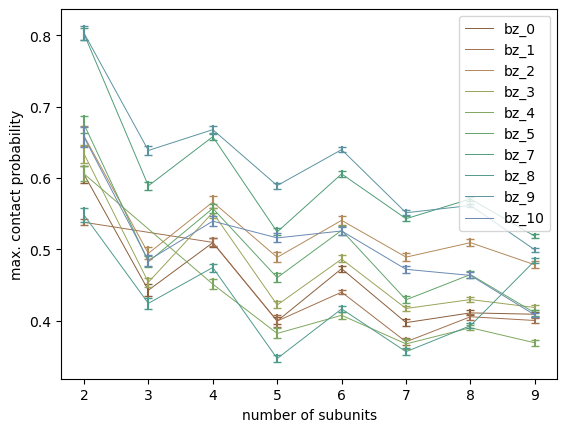

In [52]:
if not os.path.exists(f'analysis-1-cluster_6_contacts.csv'):
    contacts_df = list()
    # for output in tqdm(outputs, desc='Loading contact data.'):
    for name in tqdm(names, desc='Loading contact data.'):
        try:
            output = AlphaFoldOutput(os.path.join('../data/genes/alphafold/af_output', name))
            contacts_df.append(get_contacts(output, min_contact_prob=0.3))
        except Exception as err:
            print(f'Skipping {name}, {err}.')
    contacts_df = pd.concat(contacts_df)
    contacts_df.to_csv('analysis-1-cluster_6_contacts.csv', index=False)
else:
    contacts_df = pd.read_csv('analysis-1-cluster_6_contacts.csv')


# Get the highest contact probability for each model    
figure_df = contacts_df.copy() #sort_values('contact_prob', ascending=False).drop_duplicates(['name', 'model'])
figure_df['num_subunits'] = figure_df.name.apply(get_num_subunits)
figure_df['genome_id'] = figure_df.name.apply(get_genome_id)
figure_df['tmh_start'] = figure_df.genome_id.map(genes_df.set_index('genome_id').tmh_start)

filter_ = (figure_df.residue_num_0 > figure_df.tmh_start) | (figure_df.residue_num_1 > figure_df.tmh_start)
print(f'Removing {filter_.sum()} contacts involving transmembrane helices.')
figure_df = figure_df[~filter_].copy()

fig, ax = plt.subplots()
y = 'contact_prob'

sns.lineplot(figure_df, x='num_subunits', y=y, hue='genome_id', lw=0.7, palette=GENOME_ID_COLORS, zorder=-1, legend=True, err_style='bars', err_kws={"capsize": 3})
# sns.scatterplot(figure_df.sort_values('iptm', ascending=False).drop_duplicates('genome_id'), x='num_subunits', y=y, hue='genome_id', palette=GENOME_ID_COLORS, s=50, zorder=10)

ax.set_ylabel('max. contact probability')
ax.set_xlabel('number of subunits')

ax.get_legend().set_title('')
# sns.move_legend(ax, loc='upper right')

plt.show()

# Based on the plots above, and examining the structures, I think oligomerization is unlikely, but dimerization is still plausible. 
# It seems as though the primary contact points are at the N-terminus around 30-100, and a helix at the C-terminus. 

# Because the terminal helix is predicted to be transmembrane, this interaction might be spurious. 


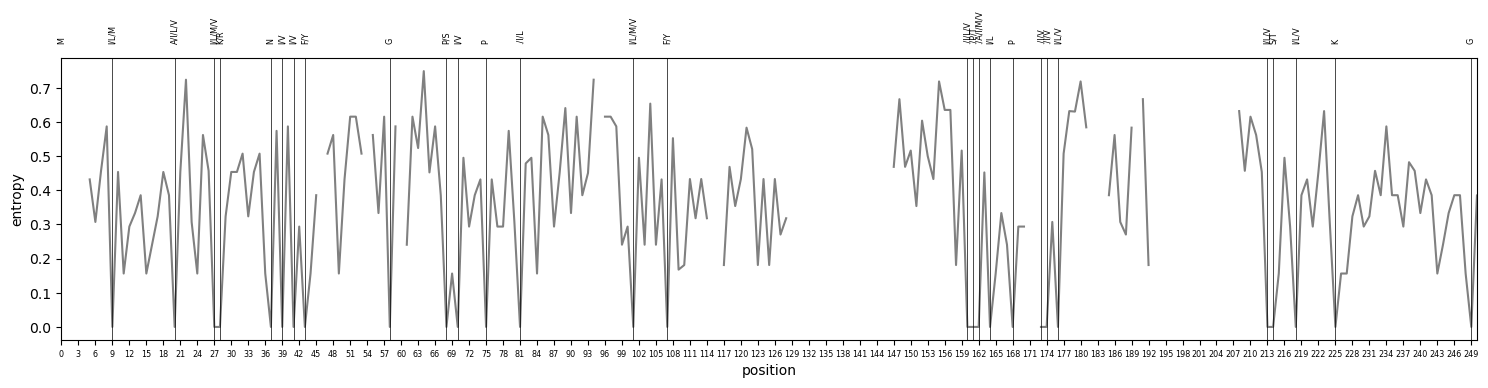

In [ ]:
def plot_entropy(msa:MSAFile, max_entropy=0.1, x_min=20, x_max=70, ax:plt.Axes=None):

    entropy = msa.get_entropy(alphabet=REDUCED_ALPHABET)

    ax.plot(np.arange(len(entropy)), entropy, color='gray')

    conserved_idxs = np.where((entropy < max_entropy) & (~np.isnan(entropy)))[0] 
    # conserved_idxs = [idx for idx in conserved_idxs if (msa.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
    conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

    for idx, aas in zip(conserved_idxs, conserved_aas):
        if (idx > x_max) or (idx < x_min):
            continue
        ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
        ax.axvline(idx, color='black', lw=0.5)

    x_ticks = np.arange(x_min, x_max, 3)
    ax.set_xticks(x_ticks, labels=x_ticks, fontsize='xx-small')
    ax.set_xlim(xmin=x_min, xmax=x_max)
    ax.set_ylabel('entropy')
    ax.set_xlabel('position')

fig, ax = plt.subplots(figsize=(15, 4), nrows=1)
plot_entropy(msa, ax=ax, x_max=250, x_min=0)


fig.tight_layout()
plt.show()


In [ ]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/level_1_conserved_clusters*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)]

filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.5
# filters['low_query_coverage'] = foldseek_search_df.query_coverage < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 50
filters['long_alignment'] = foldseek_search_df.alignment_length > 300 # Looked at some of these alignments, and all were pretty clearly garbage.
filters['synthetic'] = foldseek_search_df.target_header.str.contains('Computationally designed|synthetic|de novo|De novo|Engineered')
filters['match_to_c_terminal_helix'] = foldseek_search_df.query_start > 100 # These are all kinda meaningless. 

foldseek_search_df = apply_filters(filters, foldseek_search_df)


# Q684C2 is a good hit, which is an uncharacterized Sulfolobus virus STSV1 protein (double-stranded DNA archaeal virus). 
# Should really look into the PRC barrels more, it seems like that is exactly what this could be. Apparently homodimeric?
# P-ring formation protein FlgA hit is potentially very interesting; it is a chaperone though, it does not oligomerize. https://pmc.ncbi.nlm.nih.gov/articles/PMC4895218/

apply_filters: 11162 entries removed by low_tm_score.
apply_filters: 142 entries removed by short_alignment.
apply_filters: 4072 entries removed by long_alignment.
apply_filters: 74 entries removed by synthetic.
apply_filters: 351 entries removed by match_to_c_terminal_helix.


In [ ]:
categories = dict()
categories['ubiquitin transferase'] = foldseek_search_df.target_header.str.contains('ubiquitin', case=False)
categories['NADH-quinone oxidoreductase'] = foldseek_search_df.target_header.str.contains('quinone', case=False) # These are false positives.
categories['RimM'] = foldseek_search_df.target_header.str.contains('ribosome maturation|ribosomal RNA-processing|RimM', case=False) # Contains a PRC barrel domain at the C-terminus: N-terminal RimM domain followed by a C-terminal PRC-barrel. In Thermus thermophilus RimM, for example, the PRC-barrel was assigned to residues 98–162. https://pmc.ncbi.nlm.nih.gov/articles/PMC1951897/
categories['RNA-binding'] = foldseek_search_df.target_header.str.contains('RNA-binding', case=False) # These are false positives.
categories['srb-7'] = foldseek_search_df.target_header.str.contains('Mediator of RNA polymerase II transcription subunit 21', case=False)
categories['phosphoribosyl-AMP cyclohydrolase'] = foldseek_search_df.target_header.str.contains('Phosphoribosyl-AMP cyclohydrolase', case=False)
categories['large ribosomal subunit bL25'] = foldseek_search_df.target_header.str.contains('Large ribosomal subunit protein bL25', case=False)
categories['large ribosomal subunit bL31B'] = foldseek_search_df.target_header.str.contains('Large ribosomal subunit protein bL31B', case=False)
categories['small ribosomal subunit eS6'] = foldseek_search_df.target_header.str.contains('Small ribosomal subunit protein eS6', case=False)
categories['DUF402 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF402', case=False) # https://www.ebi.ac.uk/interpro/entry/pfam/PF04167/
categories['FlgA'] = foldseek_search_df.target_header.str.contains('FlgA', case=False)
categories['transcriptional regulator'] = foldseek_search_df.target_header.str.contains('transcriptional regulator', case=False)
categories['outer membrane lipoprotein carrier protein'] = foldseek_search_df.target_header.str.contains('lipoprotein', case=False) # Honestly looks like a decent match.
categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized|orphan', case=False)
categories['PRC barrel domain-containing protein'] = foldseek_search_df.target_header.str.contains('PRC', case=True) # The domain is conserved particularly through hydrophobic residues that stabilize the barrel, plus a nearly invariant glycine.
categories["pyridoxal 5'-phosphate synthase"] = foldseek_search_df.target_header.str.contains('phosphate synthase', case=False)
categories['BPL/LPL catalytic domain-containing protein'] = foldseek_search_df.target_header.str.contains('BPL/LPL', case=False) # An ATP-binding domain that ligates biotin or LPL to substrate proteins. 
categories = list(zip(*list(categories.items())))
foldseek_search_df['category'] = np.select(condlist=categories[-1], choicelist=categories[0], default='none')

foldseek_search_df[foldseek_search_df.category == 'none'].drop_duplicates('target_id').iloc[-100:][['alignment_length', 'percent_identity', 'query_length', 'target_length', 'query_start', 'query_end', 'target_end', 'target_header', 'alignment_tm_score']].iloc[:50]
foldseek_search_df[foldseek_search_df.category == 'RimM'].drop_duplicates('target_id').iloc[-100:][['alignment_length', 'percent_identity', 'query_length', 'target_length', 'query_start', 'query_end', 'target_start', 'target_end', 'target_header', 'alignment_tm_score']].iloc[:50]
# foldseek_search_df.sort_values('alignment_tm_score').drop_duplicates('target_id').iloc[-100:][['percent_identity', 'query_length', 'target_length', 'query_start', 'query_end', 'target_end', 'target_header', 'alignment_tm_score']].iloc[:50]

,alignment_length,percent_identity,query_length,target_length,query_start,query_end,target_start,target_end,target_header,alignment_tm_score
5480,156,2.5,226,176,13,101,19,165,AF-Q6ND66-F1-model_v6 Ribosome maturation fact...,0.5584
5481,134,4.4,226,165,15,100,41,165,AF-Q92IE7-F1-model_v6 Ribosome maturation fact...,0.5587
5482,139,5.0,226,172,14,102,41,169,AF-Q1JHF7-F1-model_v6 Ribosome maturation fact...,0.5544
5485,134,6.7,226,172,12,102,45,171,AF-B1MZT5-F1-model_v6 Ribosome maturation fact...,0.5359
5486,134,4.4,226,165,15,100,41,165,AF-A8GRQ6-F1-model_v6 Ribosome maturation fact...,0.5573
5488,137,2.9,226,172,12,102,42,169,AF-Q03JS0-F1-model_v6 Ribosome maturation fact...,0.5361
5491,148,8.1,226,164,13,147,74,163,AF-B3CTT8-F1-model_v6 Ribosome maturation fact...,0.5358
5492,136,5.8,226,168,12,102,42,168,AF-B2G819-F1-model_v6 Ribosome maturation fact...,0.5303
5494,138,4.3,226,169,10,102,42,169,AF-B2GD26-F1-model_v6 Ribosome maturation fact...,0.5217
5495,140,9.2,226,171,15,102,41,171,AF-B7HDW5-F1-model_v6 Ribosome maturation fact...,0.5541


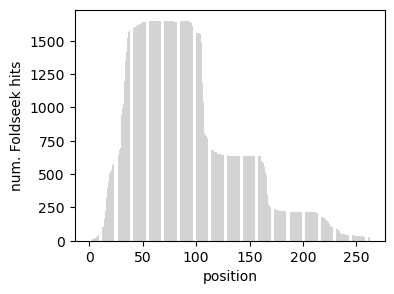

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = foldseek_search_df.copy()
figure_df = figure_df[figure_df.alignment_tm_score > 0.7].copy()
figure_df = foldseek_search_df.drop_duplicates('target_id')
# Get the indices relative to the MSAFile. 
figure_df['msa_start'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_start, row.query_id), axis=1).astype(int)
figure_df['msa_stop'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_end, row.query_id), axis=1)# .astype(int)

positions = np.arange(msa.n_cols)
heights = np.zeros(len(positions))
for row in figure_df.itertuples():
    heights[np.arange(row.msa_start, row.msa_stop)] += 1 

ax.bar(positions, heights, color='lightgray', lw=0, edgecolor='black')
ax.set_ylabel('num. Foldseek hits')
ax.set_xlabel('position')
plt.show()

# Most of the hits are to the N-terminal 200 residues, but the helix at the end (last 50 residues or so) is generally not matched. 

In [ ]:
# Copy structures over for DALI search via the web interface. 
for output_dir_name in genes_df.index:
    path = os.path.join(ALPHAFOLD_DIR, 'af_output', output_dir_name)
    output = AlphaFoldOutput(path)
    output_path = os.path.join('/home/prichter/Downloads/', f'{output_dir_name}.pdb')
    cif_to_pdb(output.best_model_path, output_path=output_path)

In [ ]:
# fig, ax = plt.subplots(figsize=(4, 4))

# figure_df = get_pairwise_alignments(genes_df.seq)
# for i in range(len(figure_df)):
#     figure_df.iloc[i, i] = 1
# figure_df = np.log(figure_df)

# sns.heatmap(figure_df, cbar=False, cmap='Blues', lw=0.7, linecolor='white')
# ax.set_ylabel('')
# ax.set_xlabel('')

# cluster_7_gene_ids.remove('orfm.bz_11.1_67')
# genes_df = pd.read_csv('../data/genes.csv', index_col=0)
# genes_df = genes_df.loc[cluster_7_gene_ids].copy()
# FASTAFile.from_df(genes_df).write('../data/genes/cluster_7.faa')

In [ ]:
# HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

# window_size = 20
# step_size = 5

# get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

# fig, axes = plt.subplots(figsize=(8, 12), nrows=len(genes_df), sharex=True)

# for ax, row in zip(axes, genes_df.itertuples()):
#     window_starts = list(range(0, len(row.seq), step_size))[:-1]
#     windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]

#     hydrophobicity = [get_hydrophobicity(seq) for seq in windows]

#     ax.plot(window_starts, hydrophobicity, label=row.Index, color=GENOME_ID_COLORS[row.genome_id])
#     ax.set_title(f'{row.Index} (num. TMHs: {row.num_tmhs})', fontsize='small')
#     # ax.set_ylabel('hydrophobicity')
#     ax.axhline(1, ls='--', color='black', lw=0.7)

# ax.set_xlabel('position')
# fig.tight_layout()
# plt.show()


In [ ]:
# DSSP_OUTPUT_DIR = '../data/genes/dssp/'
# DSSP_INPUT_DIR = '../data/genes/dssp/structures/cluster_6/'

# copy_structures(genes_df.index, source_dir='../data/genes/colabfold', output_dir=DSSP_INPUT_DIR)


# for path in glob.glob(os.path.join(DSSP_INPUT_DIR, '*')):
#     gene_id = get_gene_id(path)
#     output_path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
#     if not os.path.exists(output_path):
#         subprocess.run(f'mkdssp {path} {output_path} --output-format dssp', shell=True, check=True)

# def map_dssp_to_msa(msa):
#     ids, arr = list(), list()
#     for gene_id, map_idxs in msa.get_map_idxs().items():
#         path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
#         row = np.array(list(str(DSSPFile.from_file(path))) + ['.'])
#         arr.append(row[map_idxs])
#         ids.append(id)
#     return MSA.from_array(arr, ids)

# msa = MSA.from_file('../data/genes/cluster_6.afa')
# dssp_msa = map_dssp_to_msa(msa)